# M1 — Daily Total-Orders Forecast (count distinct Order Id)

Companion notebook to `forecast_pipeline_daily.ipynb`. The M1 demand
model in the main pipeline forecasts **quantity per order** (basket
size). This model forecasts the **number of orders per day** at the
portfolio level — `count(distinct Order Id)` — which is what the
dashboard's *Total Orders by Month-Year* panel uses.

**Source:** raw `DataCoSupplyChainDataset.csv`.
**Model:** TimesFM, pre-storm origin 2017-08-31, 334-day horizon,
sliced to Feb 1 - Jul 31 2018.
**Output:** `forecasts/m1_orders_daily.parquet`, schema matches
`m1_daily.parquet` (`product_card_id = 0` is a sentinel for the
portfolio aggregate).


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sns.set_theme(context='notebook', style='whitegrid')

ORD = pd.read_parquet(ROOT / 'forecasts' / 'm1_orders_daily.parquet')
print('shape:', ORD.shape, ' product_card_id values:', list(ORD['product_card_id'].unique()))
ORD.head(3)


shape: (1308, 7)  product_card_id values: [np.int64(0)]


,product_card_id,date,data_type,p10,p50,p90,actual
0,0,2015-01-01,Actual,NaN,NaN,NaN,58.0
1,0,2015-01-02,Actual,NaN,NaN,NaN,53.0
2,0,2015-01-03,Actual,NaN,NaN,NaN,60.0


## 1. Cross-check against raw data — should match the dashboard


In [2]:
ORD['ym'] = ORD['date'].values.astype('datetime64[M]')
hist = ORD[ORD['data_type']=='Actual']
pred = ORD[ORD['data_type']=='Prediction']

monthly = hist.groupby('ym').agg(total_orders=('actual','sum'),
                                  n_days=('actual','size')).round(0)
print('Last 12 months of actuals (count distinct Order Id):')
print(monthly.tail(12))


Last 12 months of actuals (count distinct Order Id):
            total_orders  n_days
ym                              
2017-02-01        1614.0      28
2017-03-01        1782.0      31
2017-04-01        1739.0      30
2017-05-01        1763.0      31
2017-06-01        1676.0      30
2017-07-01        1776.0      31
2017-08-01        1768.0      31
2017-09-01        1723.0      30
2017-10-01        2101.0      31
2017-11-01        2055.0      30
2017-12-01        2124.0      31
2018-01-01        2123.0      31


These numbers should match the dashboard exactly (Sep 1,723 / Oct 2,101 / Nov 2,055 / Dec 2,124 / Jan 2,123).


## 2. Daily series + forecast — full window


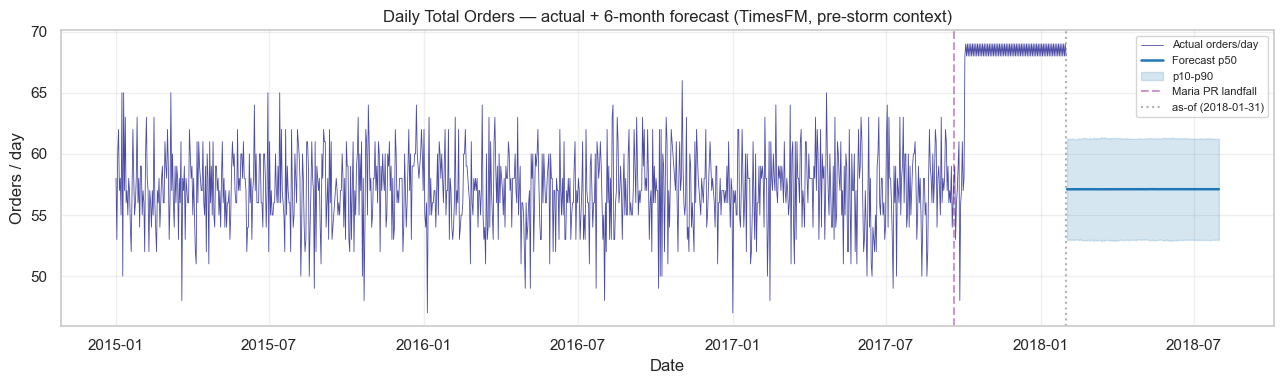

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist['date'], hist['actual'], color='navy', lw=0.6, alpha=0.7, label='Actual orders/day')
ax.plot(pred['date'], pred['p50'],    color='#1f77b4', lw=1.8, label='Forecast p50')
ax.fill_between(pred['date'], pred['p10'], pred['p90'],
                 color='#1f77b4', alpha=0.18, label='p10-p90')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray',   linestyle=':',  alpha=0.6, label='as-of (2018-01-31)')
ax.set_title('Daily Total Orders — actual + 6-month forecast (TimesFM, pre-storm context)')
ax.set_xlabel('Date'); ax.set_ylabel('Orders / day')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Monthly aggregation — same view as the dashboard


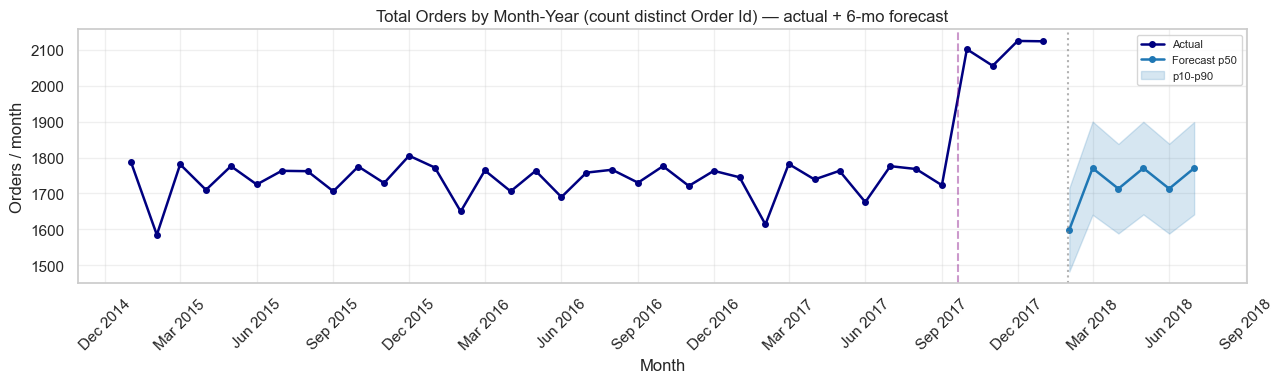

In [4]:
hist_m = hist.groupby('ym')['actual'].sum()
p10_m  = pred.groupby('ym')['p10'].sum()
p50_m  = pred.groupby('ym')['p50'].sum()
p90_m  = pred.groupby('ym')['p90'].sum()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist_m.index, hist_m.values, color='navy', lw=1.8, marker='o', ms=4, label='Actual')
ax.plot(p50_m.index, p50_m.values, color='#1f77b4', lw=1.8, marker='o', ms=4, label='Forecast p50')
ax.fill_between(p50_m.index, p10_m.values, p90_m.values, color='#1f77b4', alpha=0.18, label='p10-p90')
ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4)
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
ax.set_title('Total Orders by Month-Year (count distinct Order Id) — actual + 6-mo forecast')
ax.set_ylabel('Orders / month'); ax.set_xlabel('Month')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()


## 4. Headline forecast totals


In [5]:
print('6-month forecast (Feb-Jul 2018):')
print(f"  p10 = {pred['p10'].sum():>8,.0f}  orders")
print(f"  p50 = {pred['p50'].sum():>8,.0f}  orders  <- point forecast")
print(f"  p90 = {pred['p90'].sum():>8,.0f}  orders")
print(f"\n  daily mean p50: {pred['p50'].mean():.1f} orders/day")
print(f"  (pre-storm mean was {hist[hist['date']<=pd.Timestamp('2017-08-31')]['actual'].mean():.1f} orders/day)")


6-month forecast (Feb-Jul 2018):
  p10 =    9,585  orders
  p50 =   10,337  orders  <- point forecast
  p90 =   11,089  orders

  daily mean p50: 57.1 orders/day
  (pre-storm mean was 57.1 orders/day)


## Notes

- **Why portfolio level only.** `count(distinct Order Id)` is only meaningful at the company aggregate — one order can contain multiple products, so a per-product breakdown would double-count.
- **Why pre-storm origin.** TimesFM normalises by recent context. Feeding it the storm tail (Oct 2017 onwards, where order-count distribution shifts to ~68/day) collapses the q10-q90 band. Cutting context at 2017-08-31 preserves the normal seasonal variance.
- **No recovery damp** at this level (drag is product-specific). Portfolio order count actually *rose* post-Maria because Cohort B products spread across many tiny orders.

To re-run:
```bash
python -m src.models.demand.forecast_orders_daily
```
